This is a test to get the loa cutouts and make sure that get_cutout function works before putting in .py file and also to see what code actually works to place the fibers

In [1]:
from astropy.table import Table
from astropy.visualization.wcsaxes import SphericalCircle
from astropy import units as u
'''
import sys
sys.path.insert(1, '{}/desi/DESI_SGA/'.format(os.environ['HOME']))
try:
    from plot_funcs import plot_radec_DESI
except ModuleNotFoundError as e:
    print(e)
''';
import psycopg2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

from astropy.coordinates import SkyCoord, match_coordinates_sky

from glob import glob

from scipy.ndimage import gaussian_filter1d

from desispec.io import read_spectra
from desispec.spectra import stack as specstack
from desispec.coaddition import coadd_cameras

pix_scale = 0.25 # arcsec/pixel

import matplotlib.patheffects as patheffects
from tqdm import tqdm

## Data

In [2]:
target_galaxies = Table.read('/pscratch/sd/d/dbustos/rot_curves/loa_targs.fits')
target_galaxies[:5]

TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,SPECTYPE,DELTACHI2,ZWARN,PVTYPE,SGA_ID,PHOTSYS,DIST,DIST_R26,Selection
int64,float64,float64,float64,float64,bytes6,float64,int64,bytes3,int64,bytes1,float64,float64,int64
2350675715424256,239.8472,31.7866,0.1492904161251356,1.9422911736100356e-05,GALAXY,5071.658419655636,0,TFT,483369,S,0.00018163397694836428,0.04183588292464746,1
2389103635070977,61.51249486530825,-17.766542165450435,0.2898542763769689,1.3051647863939431e-05,GALAXY,585.0907674431801,0,TFT,526821,S,0.015034501051441454,0.40000000781105455,1
2389161461940225,53.110693190838745,-15.204162701018703,1.41029052508368,0.00015282405234457233,GALAXY,2.055874802172184,4,TFT,431568,S,0.020469853344286103,0.4000000051000554,1
2389161461940226,53.133949122267566,-15.238404516460593,1.490823662797069,8.773021438224206e-05,GALAXY,17.411476522684097,0,TFT,431568,S,0.020469853344283147,0.4000000050999976,1
2389190650101761,49.636675196299485,-14.026544506699297,0.01713651665060884,2.0408204503181013e-05,GALAXY,56.60990794678219,0,TFT,1074364,S,0.0026515899552215774,0.40000000679324754,1


In [3]:
SGA = Table.read('/global/cfs/projectdirs/cosmo/data/sga/2020/SGA-2020.fits', 'ELLIPSE')
SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

## Table of sga id for only the loa targets

In [4]:
SGA_dict = {}
for i in range(len(SGA)):
    SGA_dict[SGA['SGA_ID'][i]] = i

In [5]:
#creates empty columns to add to target_galaxies for classifications
SGA['loa'] = 0

for i in tqdm(np.unique(target_galaxies['SGA_ID'])):

    #identify all gaalxy targets
    targ_id = target_galaxies['SGA_ID'] == i

    #find the index for this target in SGA
    sga_id = SGA_dict[i]

    SGA['loa'][sga_id] = 1

100%|██████████| 1124/1124 [00:00<00:00, 26314.92it/s]


In [37]:
SGA_loa = SGA[SGA['loa']==1]
SGA_loa[:10]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,loa
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,int64
425,SGA-2020 425,PGC049409,49409,208.542678,44.2133617,SBbc,30.13,0.3981072,0.8128305,0.06368206,22.381481,15.753,False,LEDA-20181114,121,PGC049409_GROUP,2,True,208.54602188490358,44.21081193404006,0.6080715,2083p442,208.54261517279625,44.21336719329461,0.5329004,SB26,29.398323,0.76350456,208.54244265884032,44.2135020286059,13.286062,4.910831,4.4874635,2.994671,7.906555,9.092144,10.197503,11.260192,12.233587,13.004084,14.062565,14.935026,15.987012,15.997503,15.3831835,14.9915285,15.892004,15.285641,14.910577,15.828795,15.227365,14.861485,15.7904625,15.190083,14.831137,15.766502,15.166609,14.814155,15.752086,15.153393,14.806333,15.74006,15.14252,14.803116,15.73508,15.138399,14.805074,15.732069,15.134918,14.809265,0.035009358,0.05021873,0.048667938,0.053922795,0.10604824,0.10777367,0.12476239,0.10753901,0.14136124,0.012058165,0.013741603,0.020537226,0.011274149,0.01279831,0.019184649,0.010805588,0.012251667,0.018415827,0.010514686,0.0119154025,0.017966362,0.0103335725,0.011707147,0.017724745,0.01023792,0.011560682,0.01748609,0.010143652,0.011465001,0.017451182,0.010105025,0.011431337,0.017492471,0.010082828,0.011399948,0.01756689,15.719012,0.19571984,0.83850664,5.6243095,0.10244078,15.124254,0.15408316,1.0596911,6.013549,0.07396622,14.803934,0.0495287,2.64035,11.796646,0.19014192,0,1
5568,SGA-2020 5568,NGC5313,49069,207.43480200000002,39.9847415,SABb,42.1,1.8113401,0.5821032,0.008472527,22.567482,12.649,False,LEDA-20181114,1495,NGC5313,1,True,207.43480200000002

In [94]:
#Get cutouts
import requests

from astropy.wcs import WCS

import os

pix_scale = 0.25 # arcsec/pixel

def get_cutout(sgaid, ra, dec, size, dr = 11, zoom = 14, dir = '', verbose=False):
    """Grab and save legacy survey cutouts.
    
    Parameters
    ----------
    sgaid : int
        SGA galaxy ID.
    ra : float
        Right ascension (degrees).
    dec : float
        Declination (degrees).
    size: int
        Number of pixels to make cutout
    dr: int, optional
        data release to get cutout from. Options are 9, 10, and 11. Defaults to 11
    zoom: int, optional
        How zoomed in you want the cutout. Defaults to 14 
    dir : 'str', optional
        Enter the directory you want the cutout to save in. Defaults to cache
    verbose : bool, optional
        Add some status messages if true
        
    Returns
    -------
    img_name : str
        Name of JPG cutout file written after query.
    w : astropy.wcs.WCS
        World coordinate system for the image.
    """
    # Either load an existing image or download a cutout.
    img_name = (dir) + 'sga_{}.jpg'.format(sgaid)

    if dr == 11:
        layer = 'ls-dr11-early-v2'
    if dr == 10:
        layer = 'ls-dr10'
    if dr == 9:
        layer = 'ls-dr9'
    
    if os.path.exists(img_name):
        if verbose:
            print('{} exists.'.format(img_name))
    else:
        img_url = 'https://www.legacysurvey.org/viewer/cutout.jpg?ra={}&dec={}&%22/pix={}&layer={}&size={}&zoom={}&sga'.format(ra, dec, pix_scale, layer, size, zoom)
        if verbose:
            print('Get {}'.format(img_url))
            
        with open(img_name, 'wb') as handle: 
            response = requests.get(img_url, stream=True) 
            if not response.ok: 
                print(response) 
            for block in response.iter_content(1024): 
                if not block: 
                    break 
                handle.write(block)
                
    # Set up the WCS.
    wcs_input_dict = {
        'CTYPE1': 'RA---TAN',
        'CUNIT1': 'deg',
        'CDELT1': -0.262/3600,
        'CRPIX1': size/2 + 0.5,
        'CRVAL1': ra,
        'NAXIS1': size,
        'CTYPE2': 'DEC--TAN',
        'CUNIT2': 'deg',
        'CDELT2': 0.262/3600,
        'CRPIX2': size/2 + 0.5,
        'CRVAL2': dec,
        'NAXIS2': size
    }
    w = WCS(wcs_input_dict)
    
    return img_name, w

## Grab image of galaxy and put the observations on it

In [101]:
# for each rotation curve galaxy, grab cut out, draw fibers on image, and save image
for sga_id in tqdm(np.unique(target_galaxies['SGA_ID'])[:10]):
    
    targ_list = target_galaxies[target_galaxies['SGA_ID']==sga_id]
    # if np.min(targ_list['DIST_R26']) < 0.001:
    #     center_target = targ_list[np.argmin(targ_list['DIST_R26'])]['TARGETID']
    z = targ_list[np.argmin(targ_list['DIST_R26'])]['Z']

    # else:
    #     continue
    
    ra, dec = float(SGA['RA'][SGA_dict[sga_id]]), float(SGA['DEC'][SGA_dict[sga_id]])
    
    # D26 in arcmin
    d26 = SGA['D26'][SGA_dict[sga_id]]

    dr = 11

    if (d26 < 2):
        zoom = 14
    elif (d26 > 2) and (SGA['D26'][SGA_dict[sga_id]] < 4):
         zoom = 13
    elif (d26 > 4):
        zoom = 12

    npix = np.minimum(int(2 * d26*60/0.262), 512)
    

    img_file, wcs = get_cutout(sga_id, ra, dec, dr=dr, dir='/pscratch/sd/d/dbustos/loa_cutouts/cutouts/',zoom=zoom,size=npix,verbose=True)
    img = mpl.image.imread(img_file)

    fig1 = plt.figure(figsize=(7,5))

    ax = fig1.add_subplot(111, projection=wcs)
    ax.imshow(np.flip(img, axis=0))
    ax.set(xlabel='ra', ylabel='dec')
    ax.text(int(0.02*npix), int(0.85*npix), 'SGA_ID: {}\n$z={{{:.4f}}}$'.format(sga_id, z), fontsize=9, color='yellow')
    overlay = ax.get_coords_overlay('icrs')
    overlay.grid(color='white', ls='dotted');

    # Add the location of the DESI fibers.
    # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
    r1 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='black', facecolor='none', alpha=0.8, lw=3,
                         transform=ax.get_transform('icrs'))
    r2 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='red', facecolor='none', alpha=0.8, lw=2,
                         transform=ax.get_transform('icrs'))
    ax.add_patch(r1)
    ax.add_patch(r2)

    for targ in targ_list:
        ra, dec = targ['TARGET_RA'], targ['TARGET_DEC']
        
        edgecolor2 = 'orange'

        # Add the location of the DESI fibers.
        # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
        r1 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor='lightcoral', facecolor='none', alpha=1, lw=3,
                             transform=ax.get_transform('icrs'))
        r2 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor=edgecolor2, facecolor='none', alpha=0.8, lw=2,
                             transform=ax.get_transform('icrs'))
        ax.add_patch(r1)
        ax.add_patch(r2)
        
        ax.text(ra, dec, str(targ['TARGETID']), transform=ax.get_transform('icrs'), color='white', fontsize=6)
    
    fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)
    
    fig1.savefig('/pscratch/sd/d/dbustos/loa_cutouts/cutouts_fibers/' + 'fiber_sga_{}.png'.format(sga_id), dpi=120)
    
    fig1.clear()
    plt.close(fig1)


  0%|          | 0/10 [00:00<?, ?it/s]

Get https://www.legacysurvey.org/viewer/cutout.jpg?ra=208.54261517279625&dec=44.21336719329461&%22/pix=0.25&layer=ls-dr11-early-v2&size=244&zoom=14&sga


 10%|█         | 1/10 [00:00<00:04,  2.17it/s]

Get https://www.legacysurvey.org/viewer/cutout.jpg?ra=207.434668851206&dec=39.9849311275147&%22/pix=0.25&layer=ls-dr11-early-v2&size=512&zoom=13&sga


 20%|██        | 2/10 [00:00<00:03,  2.09it/s]

...

 80%|████████  | 8/10 [00:06<00:01,  1.24it/s]

Get https://www.legacysurvey.org/viewer/cutout.jpg?ra=240.05292515079398&dec=33.88808029830768&%22/pix=0.25&layer=ls-dr11-early-v2&size=251&zoom=14&sga


 90%|█████████ | 9/10 [00:07<00:00,  1.35it/s]

Get https://www.legacysurvey.org/viewer/cutout.jpg?ra=118.1812877273207&dec=24.122197058126922&%22/pix=0.25&layer=ls-dr11-early-v2&size=512&zoom=13&sga


100%|██████████| 10/10 [00:08<00:00,  1.19it/s]


In [32]:
SGA[SGA['SGA_ID']==425]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
425,SGA-2020 425,PGC049409,49409,208.542678,44.2133617,SBbc,30.13,0.3981072,0.8128305,0.06368206,22.381481,15.753,False,LEDA-20181114,121,PGC049409_GROUP,2,True,208.54602188490358,44.21081193404006,0.6080715,2083p442,208.54261517279625,44.21336719329461,0.5329004,SB26,29.398323,0.76350456,208.54244265884032,44.2135020286059,13.286062,4.910831,4.4874635,2.994671,7.906555,9.092144,10.197503,11.260192,12.233587,13.004084,14.062565,14.935026,15.987012,15.997503,15.3831835,14.9915285,15.892004,15.285641,14.910577,15.828795,15.227365,14.861485,15.7904625,15.190083,14.831137,15.766502,15.166609,14.814155,15.752086,15.153393,14.806333,15.74006,15.14252,14.803116,15.73508,15.138399,14.805074,15.732069,15.134918,14.809265,0.035009358,0.05021873,0.048667938,0.053922795,0.10604824,0.10777367,0.12476239,0.10753901,0.14136124,0.012058165,0.013741603,0.020537226,0.011274149,0.01279831,0.019184649,0.010805588,0.012251667,0.018415827,0.010514686,0.0119154025,0.017966362,0.0103335725,0.011707147,0.017724745,0.01023792,0.011560682,0.01748609,0.010143652,0.011465001,0.017451182,0.010105025,0.011431337,0.017492471,0.010082828,0.011399948,0.01756689,15.719012,0.19571984,0.83850664,5.6243095,0.10244078,15.124254,0.15408316,1.0596911,6.013549,0.07396622,14.803934,0.0495287,2.64035,11.796646,0.19014192,0


In [12]:
SGA[SGA['SGA_ID']==7474]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,loa
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,int64
7474,SGA-2020 7474,NGC4995,45643,197.419512,-7.833346499999999,SABb,97.84,2.42661,0.6194411,0.0058146887,22.46948,11.916,False,LEDA-20181114,2022,NGC4995_GROUP,3,True,197.41784579562295,-7.847156511745592,3.3221588,1975m077,197.4193681656813,-7.833210218407463,4.4776235,SB26,92.904335,0.69926655,197.41944737173074,-7.833326244654949,95.96362,35.126984,34.26078,33.892612,54.182873,64.56395,75.21543,85.53753,95.704254,106.11568,115.92617,125.32433,134.3287,11.9340315,11.243563,10.703456,11.813975,11.126542,10.588364,11.730496,11.045617,10.508916,11.678307,10.994476,10.458693,11.641245,10.958467,10.422748,11.615823,10.933673,10.397761,11.599673,10.91794,10.381643,11.589025,10.907749,10.371572,11.58181,10.900828,10.364889,0.09255107,0.15854624,0.14108287,0.11299246,0.20729348,0.17774951,0.16093159,0.25783843,0.23919338,0.0037470239,0.0036388594,0.0023127194,0.0033744567,0.0032856427,0.002108065,0.0031306774,0.0030548207,0.0020108083,0.002996071,0.0029264234,0.0018966635,0.0028922015,0.0028274339,0.0018698763,0.002826627,0.0027648732,0.0018293225,0.0027915807,0.0027318276,0.0017739977,0.0027647177,0.002706659,0.0017582144,0.002746656,0.0026896833,0.001747869,11.55209,0.27408272,1389.3445,3.627188,0.31764057,10.8723545,0.26132295,1530.6709,3.6635668,0.3261645,10.334928,0.2628936,1326.7188,3.5937848,1.3596354,0,1


In [40]:
SGA[SGA['SGA_ID']==12837]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,loa
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,int64
12837,SGA-2020 12837,PGC090800,90800,118.1812785,24.122161,Sc,40.59,0.9120108,0.15523869,0.045671925,24.97748,16.549,False,LEDA-20181114,3465,PGC090800,1,True,118.1812785,24.122161,0.9120108,1181p240,118.1812877273207,24.122197058126922,3.0994637,SB25,39.339134,0.10315853,118.18120798671545,24.12226983572125,45.725742,26.609026,25.23195,22.595638,28.706772,36.673504,43.819286,50.69396,58.05526,66.2025,74.38713,81.37434,-1.0,16.083838,15.032627,14.119245,15.860231,14.817499,13.934815,15.710207,14.675608,13.826923,15.605139,14.57724,13.763755,15.542491,14.521602,13.716084,15.49971,14.484982,13.685368,15.470194,14.4568815,13.66182,15.443299,14.434514,13.644753,-1.0,-1.0,-1.0,0.23687904,0.38500872,0.2580191,0.24470071,0.32796758,0.39792442,0.41057158,0.61285996,-1.0,0.02230655,0.021801772,0.023331549,0.019463193,0.01917489,0.020789197,0.017755019,0.017589753,0.019303279,0.016604941,0.01649027,0.018393412,0.015827756,0.015792765,0.017697368,0.015292626,0.015319748,0.017236335,0.0149277095,0.0149674285,0.016896585,0.014600135,0.01468626,0.016640466,-1.0,-1.0,-1.0,15.41004,0.25347325,1141.4521,4.2136188,0.6614976,14.408106,0.23934816,1208.1002,4.3181825,0.6202574,13.593779,0.46307474,38.2618,2.7460854,0.0619224,0,1


In [39]:
SGA[SGA['SGA_ID']==8610]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,loa
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,int64
8610,SGA-2020 8610,PGC1193898,1193898,225.21911999999998,1.4049317,E,8.09,0.6067363,0.4581419,0.0062863487,24.23548,16.692,False,LEDA-20181114,2342,PGC1193898,1,True,225.21911999999998,1.4049317,0.6067363,2251p015,225.21911047516105,1.404958032069897,1.6183172,SB26,6.6769695,0.47027993,225.21902940438946,1.4050066976712974,27.546211,52.08593,50.810883,41.6498,5.339744,8.587073,12.18329,16.069107,20.658346,26.452282,33.13035,40.685963,48.54952,18.249887,17.519573,16.996208,17.533371,16.79651,16.282547,17.097002,16.365116,15.855148,16.823298,16.09309,15.590687,16.616228,15.890448,15.394813,16.43399,15.71288,15.231919,16.286135,15.567914,15.098309,16.16786,15.450952,14.982207,16.082623,15.365343,14.900413,0.051493134,0.102621056,0.112777345,0.15084225,0.16849592,0.15122832,0.21674567,0.25480855,0.3429906,0.016997121,0.01747777,0.018484268,0.015759379,0.01622899,0.017220974,0.014289353,0.014658185,0.015535844,0.012779341,0.013087211,0.013851483,0.011369591,0.011654429,0.012370406,0.010036681,0.01032373,0.0110936025,0.008971805,0.009242331,0.010040612,0.008156733,0.0084076505,0.009132698,0.0075956373,0.007822912,0.008524781,15.296356,43.007187,0.048454795,0.61184615,1.0147734,14.592495,67647.38,2.9642857e-05,0.6028966,0.99147254,14.220736,66900.21,2.78509e-05,0.6354201,2.1137698,0,1


Get https://www.legacysurvey.org/viewer/cutout.jpg?ra=228.3770803831908&dec=5.423191398593787&%22/pix=0.25&layer=ls-dr11-early-v2&size=116&zoom=14&sga2020


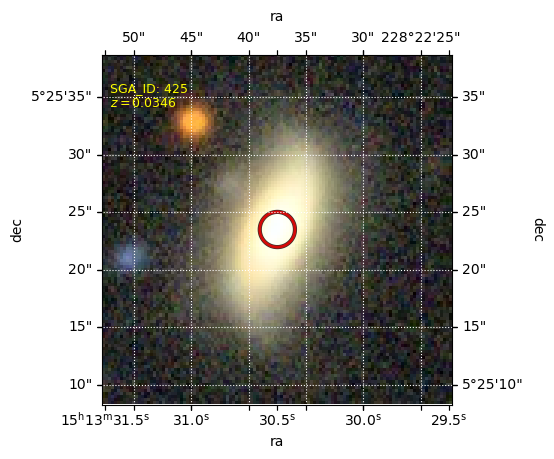

In [11]:
for i in range(1):
    
    # Retrieve SGA ID of galaxy
    sga_id = SGA_loa['SGA_ID'][i]
    
    # Coordinates of SGA galaxy's center   
    ra, dec, z = float(SGA['RA'][i]), float(SGA['DEC'][i]), float(SGA['Z_LEDA'][i])
    
    # D26 in arcmin
    d26 = SGA['D26'][i]
    
    #---------------------------------------------------------------------------
    # Padd the image cutout of the galaxy.
    # Multiply by 60 (to arcsec), divide by 180 to get pixscale.
    npix = np.minimum(int(1.025 * d26*60/0.262), 512)
    
    #print(targetid, sga_id, ra, dec)
    img_file, wcs = get_cutout(sga_id, ra, dec, npix, verbose=True)
    img = mpl.image.imread(img_file)

    fig1 = plt.figure(figsize=(7,5))

    ax = fig1.add_subplot(111, projection=wcs)
    ax.imshow(np.flip(img, axis=0))
    ax.set(xlabel='ra', ylabel='dec')
    ax.text(int(0.02*npix), int(0.85*npix), 'SGA_ID: {}\n$z={{{:.4f}}}$'.format(sga_id, z), fontsize=9, color='yellow')
    overlay = ax.get_coords_overlay('icrs')
    overlay.grid(color='white', ls='dotted');
    #---------------------------------------------------------------------------
    
    #---------------------------------------------------------------------------
    # Add the location of the center DESI fiber.
    # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
    r1 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='black', facecolor='none', alpha=0.8, lw=3,
                         transform=ax.get_transform('icrs'))
    r2 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='red', facecolor='none', alpha=0.8, lw=2,
                         transform=ax.get_transform('icrs'))
    ax.add_patch(r1)
    ax.add_patch(r2)
    #---------------------------------------------------------------------------

    tf_list = target_galaxies[target_galaxies['SGA_ID'] == sga_id]
    
    # Only keep targets at 0.4R26
    SGA_coords = SkyCoord(ra=ra, dec=dec, unit=u.degree)
    target_coords = SkyCoord(ra=tf_list['TARGET_RA'], dec=tf_list['TARGET_DEC'], unit=u.degree)
    sep2d = target_coords.separation(SGA_coords)
    sep2d_r26 = 2*sep2d.to('arcmin')/(d26*u.arcmin)
    tf_list_0p4 = tf_list[(sep2d_r26 > 0.35) & (sep2d_r26 < 0.45)]

    for i in range(len(tf_list_0p4)):
        ra, dec = tf_list_0p4['RA'][i], tf_list_0p4['DEC'][i]
        
        edgecolor2 = 'orange'
        
        # Add the location of the DESI fibers.
        # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
        r3 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor='lightcoral', facecolor='none', alpha=1, lw=3,
                             transform=ax.get_transform('icrs'))
        r4 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor=edgecolor2, facecolor='none', alpha=0.8, lw=2,
                             transform=ax.get_transform('icrs'))
        ax.add_patch(r3)
        ax.add_patch(r4)
        
        ax.text(ra, dec, str(tf_list_0p4['TARGETID'][i]), 
                transform=ax.get_transform('icrs'), 
                color='white', 
                path_effects=[patheffects.withStroke(linewidth=1, foreground='black')])
    
    fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)
    
    #fig1.savefig('/pscratch/sd/d/dbustos/rot_curves'.format(sga_id), dpi=120)
    
    #fig1.clear()
    #plt.close(fig1)

image_dir_sga_425.jpg exists.
image_dir_sga_5568.jpg exists.
image_dir_sga_7474.jpg exists.
image_dir_sga_7880.jpg exists.
image_dir_sga_8610.jpg exists.


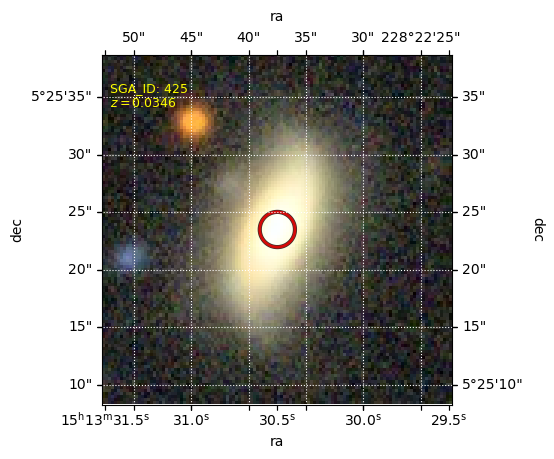

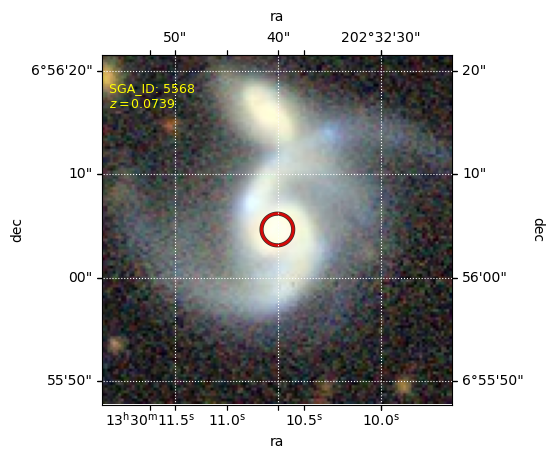

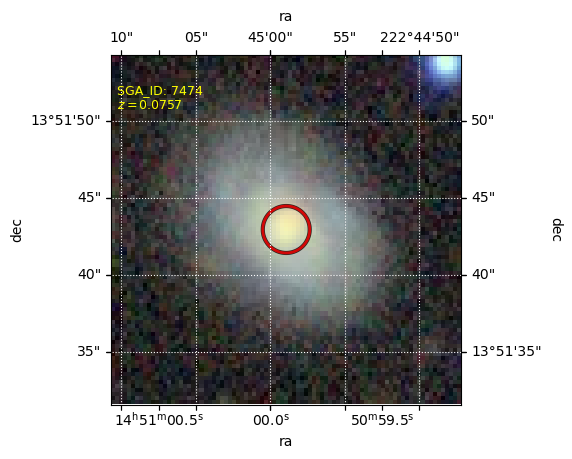

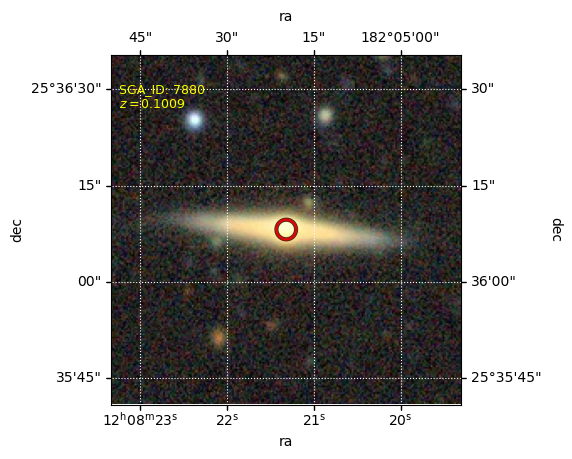

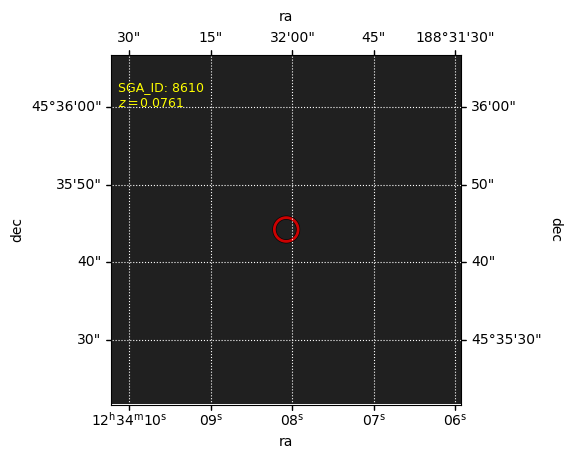

In [14]:
for i in range(len(SGA_loa[:5])):
    
    # Retrieve SGA ID of galaxy
    sga_id = SGA_loa['SGA_ID'][i]
    
    # Coordinates of SGA galaxy's center   
    ra, dec, z = float(SGA['RA'][i]), float(SGA['DEC'][i]), float(SGA['Z_LEDA'][i])
    
    # D26 in arcmin
    d26 = SGA['D26'][i]
    
    #---------------------------------------------------------------------------
    # Padd the image cutout of the galaxy.
    # Multiply by 60 (to arcsec), divide by 180 to get pixscale.
    npix = np.minimum(int(1.025 * d26*60/0.262), 512)
    
    #print(targetid, sga_id, ra, dec)
    img_file, wcs = get_cutout(sga_id, ra, dec, npix, verbose=True)
    img = mpl.image.imread(img_file)

    fig1 = plt.figure(figsize=(7,5))

    ax = fig1.add_subplot(111, projection=wcs)
    ax.imshow(np.flip(img, axis=0))
    ax.set(xlabel='ra', ylabel='dec')
    ax.text(int(0.02*npix), int(0.85*npix), 'SGA_ID: {}\n$z={{{:.4f}}}$'.format(sga_id, z), fontsize=9, color='yellow')
    overlay = ax.get_coords_overlay('icrs')
    overlay.grid(color='white', ls='dotted');
    #---------------------------------------------------------------------------
    
    #---------------------------------------------------------------------------
    # Add the location of the center DESI fiber.
    # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
    r1 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='black', facecolor='none', alpha=0.8, lw=3,
                         transform=ax.get_transform('icrs'))
    r2 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                         edgecolor='red', facecolor='none', alpha=0.8, lw=2,
                         transform=ax.get_transform('icrs'))
    ax.add_patch(r1)
    ax.add_patch(r2)
    #---------------------------------------------------------------------------

    tf_list = target_galaxies[target_galaxies['SGA_ID'] == sga_id]
    
    # Only keep targets at 0.4R26
    SGA_coords = SkyCoord(ra=ra, dec=dec, unit=u.degree)
    target_coords = SkyCoord(ra=tf_list['TARGET_RA'], dec=tf_list['TARGET_DEC'], unit=u.degree)
    sep2d = target_coords.separation(SGA_coords)
    sep2d_r26 = 2*sep2d.to('arcmin')/(d26*u.arcmin)
    tf_list_0p4 = tf_list[(sep2d_r26 > 0.35) & (sep2d_r26 < 0.45)]

    for i in tf_list:
        ra, dec = i['TARGET_RA'], i['TARGET_DEC']
        
        edgecolor2 = 'orange'
        
        # Add the location of the DESI fibers.
        # SDSS fibers are 2" diameter, DESI is 107 um with 70 um/" plate scale.
        r3 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor='lightcoral', facecolor='none', alpha=1, lw=3,
                             transform=ax.get_transform('icrs'))
        r4 = SphericalCircle((ra * u.deg, dec * u.deg), (107./70) * u.arcsec,
                             edgecolor=edgecolor2, facecolor='none', alpha=0.8, lw=2,
                             transform=ax.get_transform('icrs'))
        ax.add_patch(r3)
        ax.add_patch(r4)
        
        # ax.text(ra, dec, str(tf_list['TARGETID'][i]), 
        #         transform=ax.get_transform('icrs'), 
        #         color='white', 
        #         path_effects=[patheffects.withStroke(linewidth=1, foreground='black')])

    fig1.subplots_adjust(top=0.85, right=0.85, bottom=0.15, left=0.15)
    
    #fig1.savefig('/pscratch/sd/d/dbustos/rot_curves'.format(sga_id), dpi=120)
    
    #fig1.clear()
    #plt.close(fig1)

In [18]:
get_cutout?

Signature: get_cutout(sgaid, ra, dec, size, image_dir='cache/', verbose=False)
Docstring:
Grab and save legacy survey cutouts.

Parameters
----------
sgaid : int
    SGA galaxy ID.
ra : float
    Right ascension (degrees).
dec : float
    Declination (degrees).
image_dir : 'str', optional
    Enter the directory you want the cutout to save in. Defaults to 'cache/'
verbose : bool, optional
    Add some status messages if true
    
Returns
-------
img_name : str
    Name of JPG cutout file written after query.
w : astropy.wcs.WCS
    World coordinate system for the image.
File:      /global/u1/d/dbustos/DESI_SGA/TF/rot_curves/Y3/get_cutouts.py
Type:      function